Owen Graham (OG89) and Luca Gabella (LMG49)

## Abstract

This report applies mutliple machine learning classification methods to predict wine quality based on 11 predictor variables. Using the dataset provided, we transformed the quality ratings into a binary classification problem distinguishing between below and above average wines. We implemented and compared a number of classification methods which were: Logistic Regression with both L1 and L2 regularisation penalties, Support Vector Machines, KNN, Random Forest, Gradient Boosting and Neural Networks. Our early Exploratory Data Analysis revealed multicollinearity between the predictor variables which justified the use of the L1 and L2 penalty regularisation techniques, Cross Validation was also applied. Random Forest achieved the highest prediction accuracy of approximately 79% with an optimal m value of 2, showing that ensemble methods outperformed individual classifiers. Ridge and Lasso regularisation improved model interpretabiity by identifying the most influential predictor variables whilst reducing overfitting. Overall it was ensemble methods that were more important for the wine classification.

## Introduction

The assessment of the quality of wine traditionally relies on a sensory evaluation which can be subjective and time consuming. The ability to predict the quality of wine from objective variables offers significant value in determining production value of certain tyes of wine. Machine learning classification methods offer an approach to this by identifying patterns in these predictor variables that correlate with the quality of the wine. This report looks at the binary classification problem of distinguishing wine between below average, a quality rating of 5 and below, and above average, with a quality rating of 6 and higher based on 11 provided predictor variables. We used multiple classification approaches to compare their effectivenesses and determine the most accurate models for prediction. 

We started with using the Generalised Linear Model of Logistic Regression to provide a baseline we could then compare to when using L1 and L2 regularisation penalties, being Lasso and Ridge Regression. These were also used to address the multicollinearity between predictor variables found in our EDA. Support Vector Machines with RBF were used to handle non linear relationsips, and then KNN was used as a distance based approach. We then used two ensemble methods of Random Forest and Gradient Boosting to combine weak learners to improve prediction accuracy. We finished with Neural Networks as a form of deep learning.

All models were trained and tested on an 80/20 respective split and used the random seed of 42 to allow for reproducability of results.

## Libraries and Importing the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
import scipy.stats as stats
import seaborn as sns



In [2]:
df= pd.read_csv('WineQT.csv')

## EDA

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
None


This is an overall overview of our dataset which shows some key information about our data. The first insight is that we have 1143 entries in our data, which means it should not be computationally expensive to fit our models but should have enough values to be of statistical significance. The second key piece is that there are no missing values in this dataset. If comparing the total entries at the beginning of the output with the number found in the Non-Null Count column, they are the same for all features. This means there are no missing values anywhere in the dataset. Finally all of the features are of a numeric data type, which will ensure compatibility with all the models to be fitted. 
Something else that requires further investigation is the "Id" column. If this column is simply a numbered value ranging from 1 or 0 to 1143 it will be redundant in our dataset. 

0          0
1          1
2          2
3          3
4          4
        ... 
1138    1592
1139    1593
1140    1594
1141    1595
1142    1597
Name: Id, Length: 1143, dtype: int64
{'whiskers': [<matplotlib.lines.Line2D object at 0x30f02ffd0>, <matplotlib.lines.Line2D object at 0x30f2e9110>], 'caps': [<matplotlib.lines.Line2D object at 0x30f07b610>, <matplotlib.lines.Line2D object at 0x30f2ea790>], 'boxes': [<matplotlib.lines.Line2D object at 0x30f2e3250>], 'medians': [<matplotlib.lines.Line2D object at 0x30f2eb310>], 'fliers': [<matplotlib.lines.Line2D object at 0x30f2ebe10>], 'means': []}


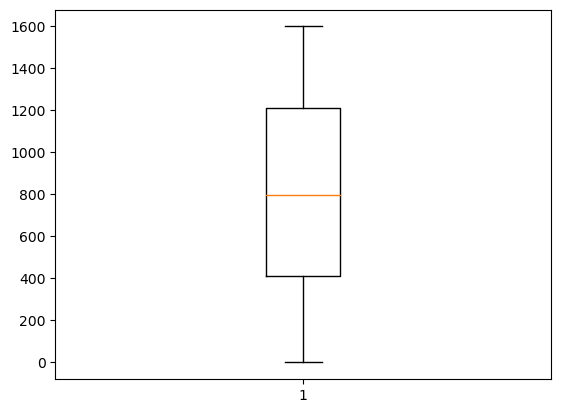

In [4]:
print(df["Id"])
print(plt.boxplot(df['Id']))

This output is slightly unusual for an Id column, since the values at the end of the column do not match with the number of entries in the dataframe. However since the Id value is strictly increasing by an integer amount, it does not have any correlation with the rest of the features in the row. So it is safe to drop this column from the dataframe. 

In [5]:
df = df.drop(columns="Id")

Next we will begin examining the quality feature of our data, since that is the feature we are attempting to predict with our models. Since the column is made up of integers, a simple bar chart showing the counts of each value will serve as a histogram.

<Axes: xlabel='quality'>

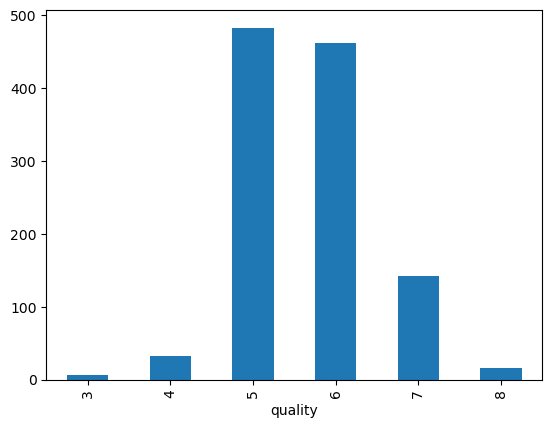

In [6]:
quality_counts = df.value_counts("quality").sort_index()
quality_counts.plot(kind = 'bar')

This initial histogram shows us that the data is heavily skewed towards values of 5 and 6. For the purpose of our objective to predict whether a wine is of above average quality, a simplification of the quality feature will be made. Creating a binary variable from quality means the models can focus on predicting whether the wine is of a certain quality threshold, instead of trying to specifically pick out the class. 

In [7]:

df['quality'] = df['quality'].apply(lambda x: 1 if x > 5 else 0)
pd.crosstab(df['quality'], 'Quality %') / len(df)

col_0,Quality %
quality,
0,0.456693
1,0.543307


After splitting the quality feature, the proportions of the two classes are shown. These features are almost perfectly split, so no further altercations within the models need to be made. 

Next, an assessment of all the other features within the dataset. 

fixed acidity              Axes(0.125,0.747241;0.227941x0.132759)
volatile acidity        Axes(0.398529,0.747241;0.227941x0.132759)
citric acid             Axes(0.672059,0.747241;0.227941x0.132759)
residual sugar             Axes(0.125,0.587931;0.227941x0.132759)
chlorides               Axes(0.398529,0.587931;0.227941x0.132759)
free sulfur dioxide     Axes(0.672059,0.587931;0.227941x0.132759)
total sulfur dioxide       Axes(0.125,0.428621;0.227941x0.132759)
density                 Axes(0.398529,0.428621;0.227941x0.132759)
pH                      Axes(0.672059,0.428621;0.227941x0.132759)
sulphates                   Axes(0.125,0.26931;0.227941x0.132759)
alcohol                  Axes(0.398529,0.26931;0.227941x0.132759)
dtype: object

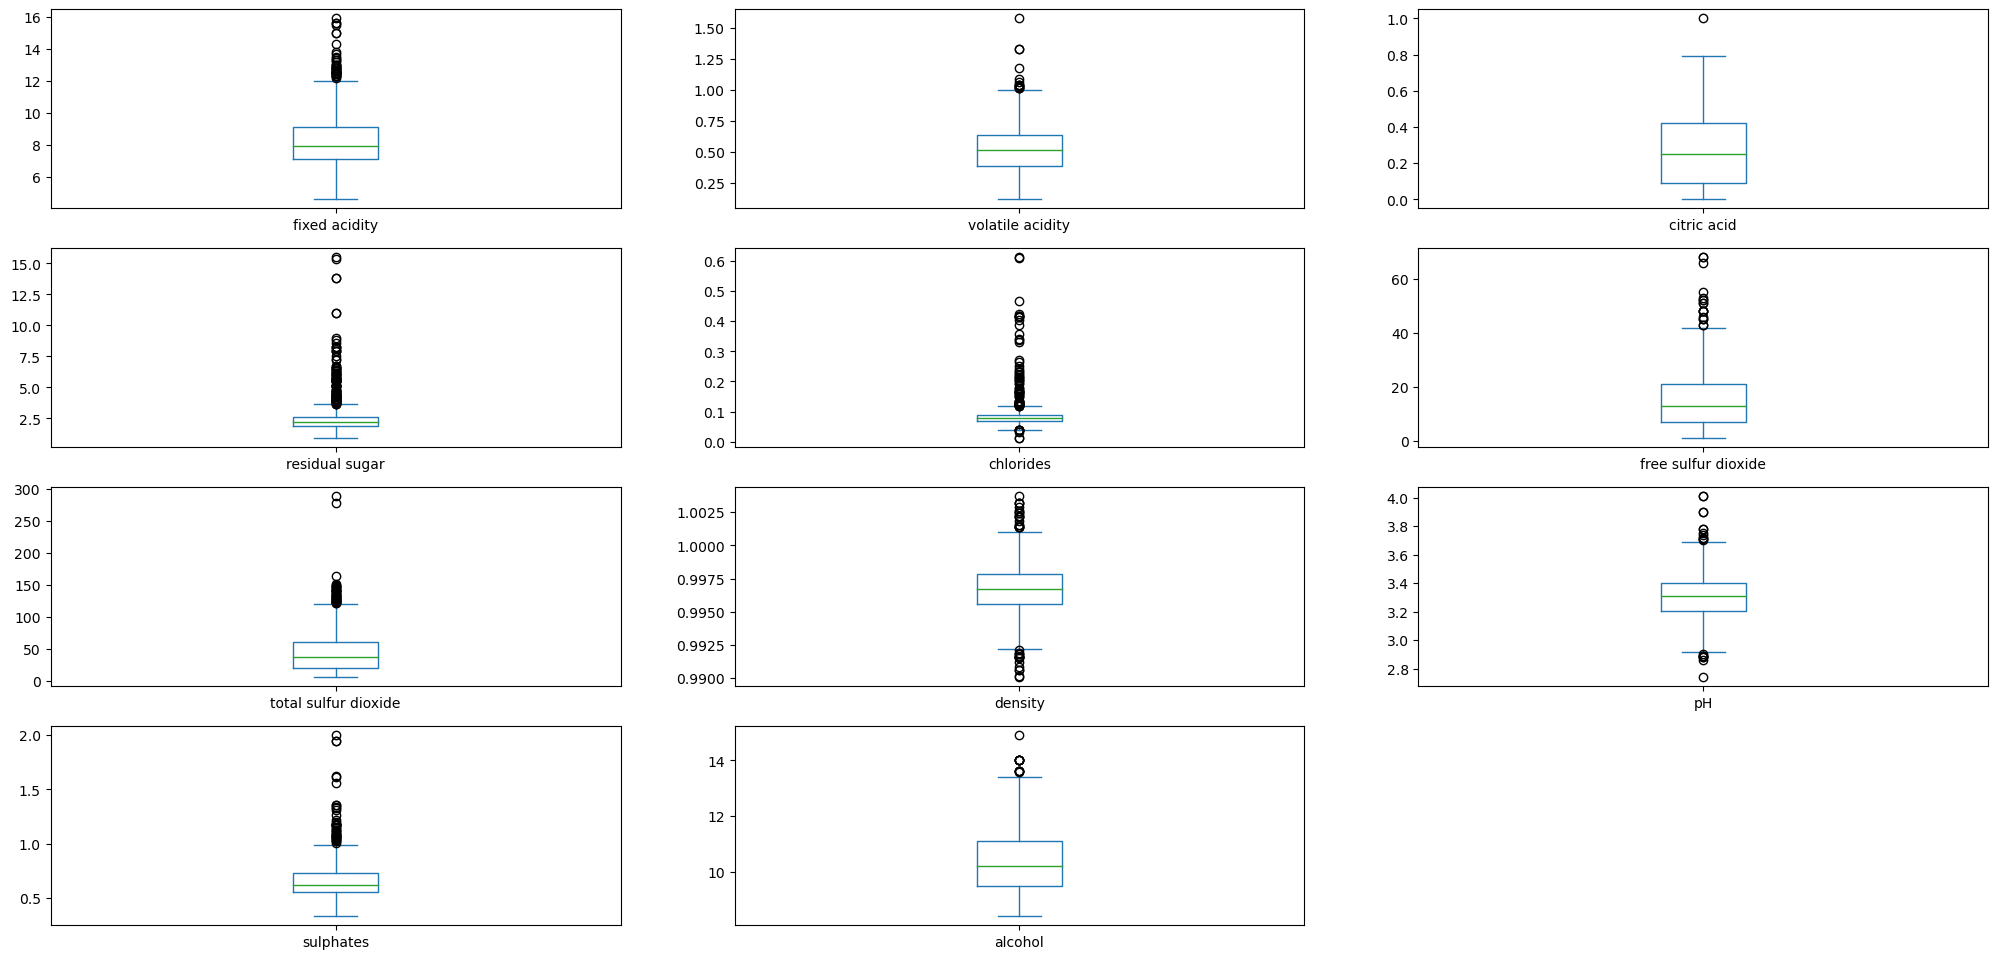

In [8]:
df.loc[:, ~df.columns.isin(['quality'])].plot( 
    kind = 'box', 
    subplots= True, 
    layout = (5,3),
    figsize= (25,15), 
    sharex=False)

The first thing to note is that all the features take values in various ranges. So scaling will need to be applied to the data for certain models. That will be executed and explained on a model by model basis. Secondly, some features have a large number of outliers. This is especially prevalent with the residual sugar and chlorides features. 

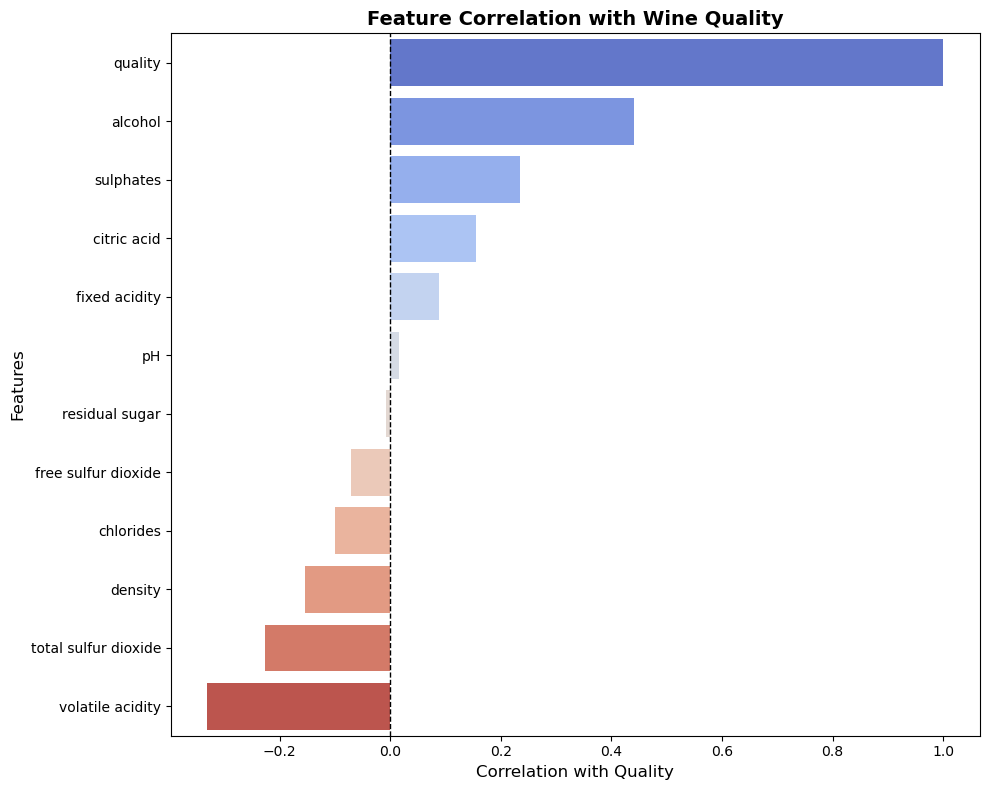

In [9]:
colin = df.corr()
plt.figure(figsize=(10, 8))
colin_quality = colin['quality'].sort_values(ascending= False)
sns.barplot(x = colin_quality.values, y = colin_quality.index, palette= 'coolwarm')
plt.xlabel('Correlation with Quality', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Correlation with Wine Quality', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()


A graph was plotted based on the correlation between the predictor variables and the quality variable to determine overall correlation we could later use to the compare to the cooefficients to see if our predictive models match up to the original correlation to the overall dataset. The pandas .corr() method allowed us to graph the correlations on a heatmap where red showed an inverse correlation and blue showed a direct correlation between them. This allowed us to see that alcohol content and sulphates had the highest direct correlations whilst total sulfur dioxide and volatile acidity had the highest inverse correlations with the quality of the wine.

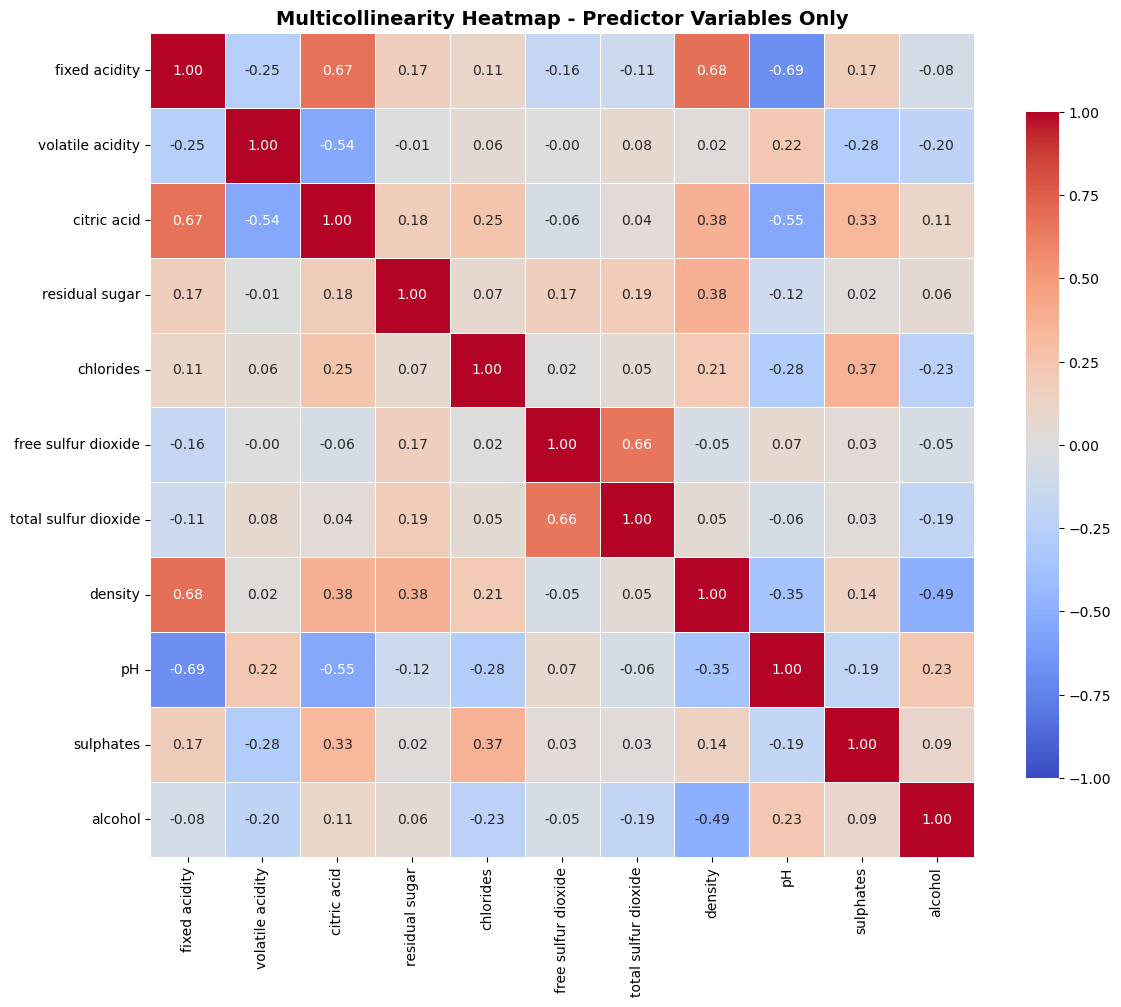


Highly Correlated Feature Pairs (|correlation| > 0.6):
fixed acidity             <-> citric acid              : 0.673
fixed acidity             <-> density                  : 0.682
fixed acidity             <-> pH                       : -0.685
free sulfur dioxide       <-> total sulfur dioxide     : 0.661


In [10]:
predictors_colin = df.drop('quality', axis=1).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(predictors_colin, annot=True, cmap='coolwarm',
center=0, fmt='.2f', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1)
plt.title('Multicollinearity Heatmap - Predictor Variables Only',
fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print highly correlated pairs (potential multicollinearity issues)
print("\nHighly Correlated Feature Pairs (|correlation| > 0.6):")
print("=" * 60)
for i in range(len(predictors_colin.columns)):
    for j in range(i+1, len(predictors_colin.columns)):
        if abs(predictors_colin.iloc[i, j]) > 0.6:
            feat1 = predictors_colin.columns[i]
            feat2 = predictors_colin.columns[j]
            corr_val = predictors_colin.iloc[i, j]
            print(f"{feat1:25s} <-> {feat2:25s}: {corr_val:.3f}")

One we had the correlations between the predictor variables and quality we wanted to look for multicollinearity between the predictor variables to help us decide on the right classification methods to use. Using 0.6 as the threshold for colinearity, we used a heatmap graph with only the predictor variables allowing us to see that there were four pairs of collinear variables. These were fixed acidity and citric acid; fixed acidity and density; fixed acidity and pH; and free sulfur dioxide with total sulfur dioxide. With this amount of pairs we were able to determine that later using ridge regression would be beneficial to help reduce mulitcollinearity.

## Training Test Split

An important step to take when assessing a model is how it preforms on data it has not seen yet. Otherwise, the model can overfit to the training data and there will be no way of telling. For that purpose a training test split will be conducted, where the model will train on the training data and be assessed on how it classifies the test data

In [11]:
from sklearn import model_selection
X, y = df[df.columns[1:11]], df['quality']
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(
    X, y, test_size = 0.2, random_state = 42
)
y_train.value_counts() / len(y_train)

quality
1    0.540481
0    0.459519
Name: count, dtype: float64

This creates an 80/20 training/testing split for the data using the random seed of 42. When checking the distribution of classes in the training set, they have maintained the proportions of the original data set. 

## Logistic Regression

In [12]:
from sklearn import linear_model, metrics


logistic_model = sk.linear_model.LogisticRegression(max_iter=1000, random_state=42)     # Create the Logistic Regression model using sklearn
logistic_model.fit(X_train, y_train)                                                    # Fit the model with the training set data

y_pred_logistic = logistic_model.predict(X_test)                                        # Use the fitted model to make predictions 

cm_logistic = metrics.confusion_matrix(y_test, y_pred_logistic)                         # Create a confusion matrix based on the results from the predictive model


This creates a Logistic Regression model for the training data that we could then use to make predictions on the testing data, due to turning the quality data into binary groups Logistic Regression was the right classification method to use over Linear Regression. Logistic Regression works by using a Sigmoid function to convert binary inputs into a probability value between 0 and 1. The binary classification for the inputs are 0 for quality values of 5 and below, and 1 for quality values of 6 and above. This works by taking the Linear Regression function continuous value output and applying the Sigmoid function to it to give it a probability. Z represents the continuous value from Linear Regression and σ represents the probability. As Z approaches infinity, σ tends towards 1, and as Z approaches negative infinity, σ tends towards 0, σ is always bounded between 0 and 1.

The probability of being in a class can then be measures as P(y = 1) = σ(Z) and P(y = 0) = 1 - σ(Z), where y is the input value.

In [13]:
tn, fp, fn, tp = cm_logistic.ravel()                        # Ravel the true negatives, false positives, false negatives and true positives from the confusion matrix

accuracy = (tp +tn) / (tp +tn +fp +fn)                      # Calculate overall accuracy, proportion of correct predictions vs population
sensitivity = (tp) / (tp + fn)                              # Calculate senstivity, proportion of true positives vs correct positives
specificity = (tn) / (tn + fp)                              # Calculate specificity, proportion of true negatives vs correct negatives
ppv = (tp) / (tp + fp)                                      # Calculate positive predictive value, proportion of true positives vs total predicted positives
npv = (tn) / (tn + fn)                                      # Calculate negative predictive value, proportion of true negatives vs total predicted negatives
prevalence = (tp + fn) / (tp + tn + fp + fn)                # Calculate prevalence, proportion of correct postives vs population
detection_rate = (tp) / (tp + tn + fp +fn)                  # Calculate detection rate, proportion of true positives vs population
detection_prevalence = (tp + fp) / (tp + tn + fp + fn)      # Calculate detection prevalence, proportion of predicted positives vs population
balanced_accuracy = (sensitivity + specificity) / 2         # Calculate balanced accuracy, mean of senstivity and specificity scores
kappa = sk.metrics.cohen_kappa_score(y_test, y_pred_logistic)        # Kappa score, 0.5 means moderate agreement

n = len(y_test)
z = 1.96
ci_lower = (accuracy + z**2/(2*n) - z * np.sqrt((accuracy*(1-accuracy) + z**2/(4*n))/n)) / (1 + z**2/n)     # Lower confidence interval at 95%
ci_upper = (accuracy + z**2/(2*n) + z * np.sqrt((accuracy*(1-accuracy) + z**2/(4*n))/n)) / (1 + z**2/n)     # Upper confidence interval at 95%

print("Confusion Matrix:")                                              # Format results in the samw why R produces the results from a confusion matrix                                                                                                                                                 
print(f"           Prediction")                                                                                                                                            
print(f"              0      1")                                                                                                                                           
print(f"Actual 0    {tn:3d}   {fp:3d}")                                                                                                                                    
print(f"Actual 1    {fn:3d}   {tp:3d}")                                                                                                                                    
print()                                                                                                                                                                   
print(f"               Accuracy : {accuracy:.4f}")                                                                                                                        
print(f"                 95% CI : ({ci_lower:.4f}, {ci_upper:.4f})")                                                                                                                                                                                                                                                                                                                                                          
print()                                                                                                                                                                    
print(f"                  Kappa : {kappa:.4f}")                                                                                                                                                                                                                          
print()                                                                                                                                                                    
print(f"            Sensitivity : {sensitivity:.5f}")                                                                                                                     
print(f"            Specificity : {specificity:.5f}")                                                                                                                      
print(f"         Pos Pred Value : {ppv:.5f}")                                                                                                                              
print(f"         Neg Pred Value : {npv:.5f}")                                                                                                                              
print(f"             Prevalence : {prevalence:.5f}")                                                                                                                       
print(f"         Detection Rate : {detection_rate:.5f}")                                                                                                                   
print(f"   Detection Prevalence : {detection_prevalence:.5f}")                                                                                                             
print(f"      Balanced Accuracy : {balanced_accuracy:.5f}")   


Confusion Matrix:
           Prediction
              0      1
Actual 0     75    27
Actual 1     26   101

               Accuracy : 0.7686
                 95% CI : (0.7098, 0.8185)

                  Kappa : 0.5311

            Sensitivity : 0.79528
            Specificity : 0.73529
         Pos Pred Value : 0.78906
         Neg Pred Value : 0.74257
             Prevalence : 0.55459
         Detection Rate : 0.44105
   Detection Prevalence : 0.55895
      Balanced Accuracy : 0.76528


Once the model had been made, predictions had been made on the test set and a confusion matrix had been made, we were able to use and format the results to be read. An accuracy of 0.7686 can be considered good in this context, with a similar sensitivity and specificity meaning the proportion of correct predictions within both categories is fairly consistent across the model. 

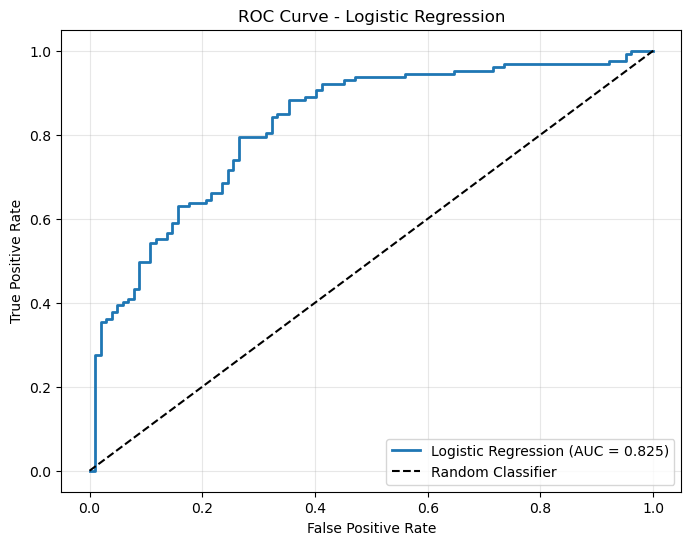

In [14]:
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]  # Get probabilities for class 1                                                                                         
fpr, tpr, thresholds = sk.metrics.roc_curve(y_test, y_pred_proba)                                                                                                                     
auc_score = sk.metrics.roc_auc_score(y_test, y_pred_proba)                                                                                                                            

plt.figure(figsize=(8, 6))                                                                                                                                                 
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.3f})', linewidth=2)                                                                                      
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')                                                                                                                 
plt.xlabel('False Positive Rate')                                                                                                                                          
plt.ylabel('True Positive Rate')                                                                                                                                           
plt.title('ROC Curve - Logistic Regression')                                                                                                                               
plt.legend()                                                                                                                                                               
plt.grid(alpha=0.3)                                                                                                                                                        
plt.show()       

We were then able to make an ROC curve from the Logistic model, the AUC being 0.825 and curve being towards the top left hand corner shows a good accuracy for the model.

## Ridge Regression

In [15]:
ridge_model =sk.linear_model.RidgeClassifier(alpha = 1, random_state=42)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

cm_ridge = sk.metrics.confusion_matrix(y_test, y_pred_ridge)
cm_ridge

array([[73, 29],
       [28, 99]])

We then ran a Ridge Regression model with an alpha as 1, using the random seed of 42 to keep in line with the reproducability of the rest of the code. We created this model and trained it in the exact same way we did the Logistic Regression as to make the classifications comparable. We will keep this in line when creating a Lasso model. Ridge Regression is used to address overfitting and multicolinearity. In our earlier EDA we used a heatmap correllation graph to understand that there is multicollinearity in the dataset. We chose an alpha of 1 to train the model on. This alpha acts as a penalty term for regularisation to the ordinary least squares objective function. The penalty causes the model to avoid using large coefficient values, by making said coefficients closer to zero, it reduces the sensitivity of the model to noise and random fluctuations in the data. We will be reffering to the penalty value as alpha as that is the name for the lambda value that sklearn uses. As alpha increases the model emphaises the shrinking of the coefficients of highly correlated predictive variables.

In [16]:
tn, fp, fn, tp = cm_ridge.ravel()                        # Ravel the true negatives, false positives, false negatives and true positives from the confusion matrix

accuracy = (tp +tn) / (tp +tn +fp +fn)                      # Calculate overall accuracy, proportion of correct predictions vs population
sensitivity = (tp) / (tp + fn)                              # Calculate senstivity, proportion of true positives vs correct positives
specificity = (tn) / (tn + fp)                              # Calculate specificity, proportion of true negatives vs correct negatives
ppv = (tp) / (tp + fp)                                      # Calculate positive predictive value, proportion of true positives vs total predicted positives
npv = (tn) / (tn + fn)                                      # Calculate negative predictive value, proportion of true negatives vs total predicted negatives
prevalence = (tp + fn) / (tp + tn + fp + fn)                # Calculate prevalence, proportion of correct postives vs population
detection_rate = (tp) / (tp + tn + fp +fn)                  # Calculate detection rate, proportion of true positives vs population
detection_prevalence = (tp + fp) / (tp + tn + fp + fn)      # Calculate detection prevalence, proportion of predicted positives vs population
balanced_accuracy = (sensitivity + specificity) / 2         # Calculate balanced accuracy, mean of senstivity and specificity scores
kappa = sk.metrics.cohen_kappa_score(y_test, y_pred_ridge)        # Kappa score, 0.5 means moderate agreement

n = len(y_test)
z = 1.96
ci_lower = (accuracy + z**2/(2*n) - z * np.sqrt((accuracy*(1-accuracy) + z**2/(4*n))/n)) / (1 + z**2/n)     # Lower confidence interval at 95%
ci_upper = (accuracy + z**2/(2*n) + z * np.sqrt((accuracy*(1-accuracy) + z**2/(4*n))/n)) / (1 + z**2/n)     # Upper confidence interval at 95%

print("Confusion Matrix:")                                              # Format results in the samw why R produces the results from a confusion matrix                                                                                                                                                 
print(f"           Prediction")                                                                                                                                            
print(f"              0      1")                                                                                                                                           
print(f"Actual 0    {tn:3d}   {fp:3d}")                                                                                                                                    
print(f"Actual 1    {fn:3d}   {tp:3d}")                                                                                                                                    
print()                                                                                                                                                                   
print(f"               Accuracy : {accuracy:.4f}")                                                                                                                        
print(f"                 95% CI : ({ci_lower:.4f}, {ci_upper:.4f})")                                                                                                                                                                                                                                                                                                                                                          
print()                                                                                                                                                                    
print(f"                  Kappa : {kappa:.4f}")                                                                                                                                                                                                                          
print()                                                                                                                                                                    
print(f"            Sensitivity : {sensitivity:.5f}")                                                                                                                     
print(f"            Specificity : {specificity:.5f}")                                                                                                                      
print(f"         Pos Pred Value : {ppv:.5f}")                                                                                                                              
print(f"         Neg Pred Value : {npv:.5f}")                                                                                                                              
print(f"             Prevalence : {prevalence:.5f}")                                                                                                                       
print(f"         Detection Rate : {detection_rate:.5f}")                                                                                                                   
print(f"   Detection Prevalence : {detection_prevalence:.5f}")                                                                                                             
print(f"      Balanced Accuracy : {balanced_accuracy:.5f}")   


Confusion Matrix:
           Prediction
              0      1
Actual 0     73    29
Actual 1     28    99

               Accuracy : 0.7511
                 95% CI : (0.6913, 0.8026)

                  Kappa : 0.4957

            Sensitivity : 0.77953
            Specificity : 0.71569
         Pos Pred Value : 0.77344
         Neg Pred Value : 0.72277
             Prevalence : 0.55459
         Detection Rate : 0.43231
   Detection Prevalence : 0.55895
      Balanced Accuracy : 0.74761


The results from the Ridge model were very similar to the results from the Logistic model once again showing good accuracy, sensitivity and specificity across the model with a kappa showing moderate agreement. The sensitivity and specificity remain similar keeping in line with consistent accuracy across the model.

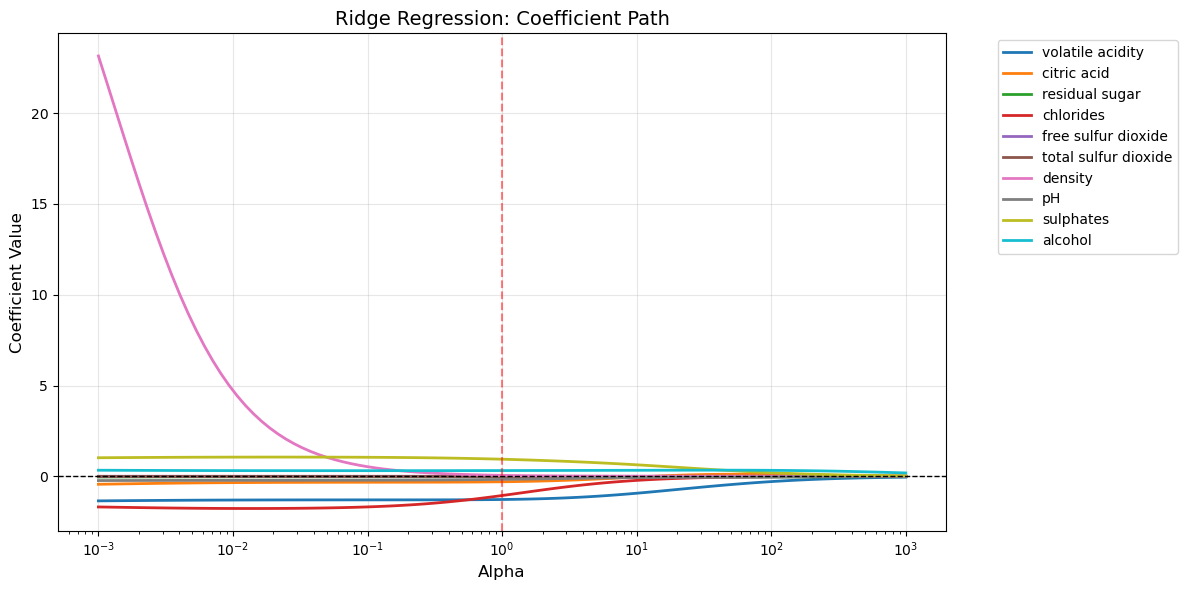

In [17]:
alphas = np.logspace(-3, 3, 100)  # Alpha from 0.001 to 1000
coefs = []

for alpha in alphas:
    ridge = sk.linear_model.RidgeClassifier(alpha=alpha)
    ridge.fit(X_train, y_train)
    coefs.append(ridge.coef_[0])

# Plot coefficient path
plt.figure(figsize=(12, 6))
for i, feature in enumerate(X_train.columns):
    plt.plot(alphas, [coef[i] for coef in coefs], label=feature, linewidth=2)

plt.xscale('log')
plt.xlabel('Alpha', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)
plt.title('Ridge Regression: Coefficient Path', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', linewidth=1)
plt.axvline(x=1.0, color='r', linestyle='--', alpha=0.5, label='Current alpha=1')
plt.tight_layout()
plt.show()

The next step was to generate a coefficient path graph using alphas between 0.001 and 1000 inclusive to see how the coefficients change. A coefficient path graph shows how the predictor variables coefficients change as the alpha increases. Variables that shrink faster are less important whereas those that take longer have more influence as predictor variables. This works by calculating the coefficients for each predictor variable as the alpha changes to plot a line for each variable on the same graph.

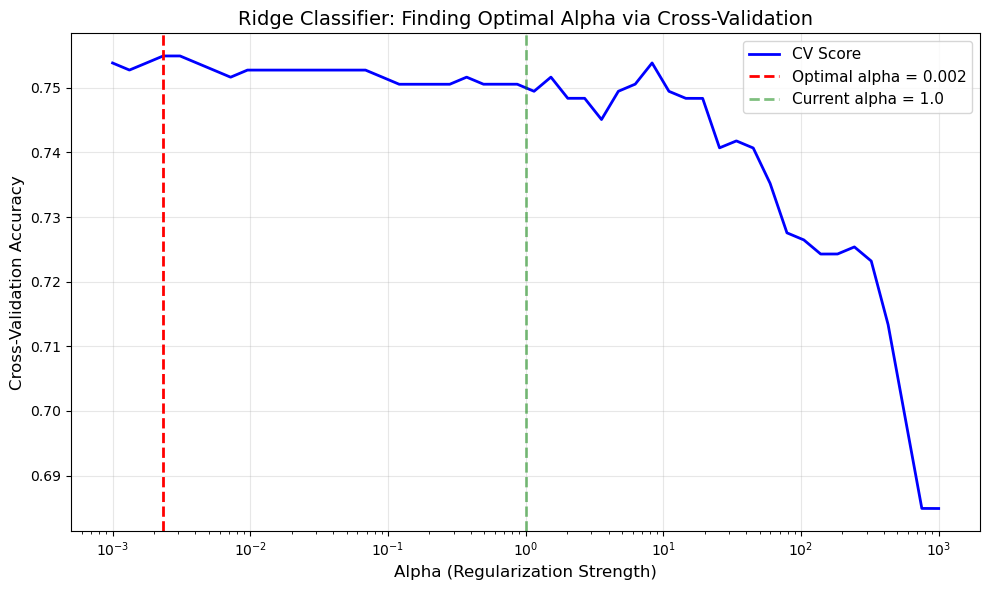


Optimal Alpha: 0.0023
Best CV Accuracy: 0.7549
Current Alpha (1.0) CV Accuracy: 0.7506


In [18]:

from sklearn.model_selection import cross_val_score

alphas = np.logspace(-3, 3, 50)
cv_scores = []

for alpha in alphas:
    ridge = sk.linear_model.RidgeClassifier(alpha=alpha)
    scores = cross_val_score(ridge, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Find optimal alpha
optimal_alpha = alphas[np.argmax(cv_scores)]
best_score = max(cv_scores)

# Plot cross-validation scores
plt.figure(figsize=(10, 6))
plt.plot(alphas, cv_scores, 'b-', linewidth=2, label='CV Score')
plt.axvline(x=optimal_alpha, color='r', linestyle='--', linewidth=2, 
            label=f'Optimal alpha = {optimal_alpha:.3f}')
plt.axvline(x=1.0, color='g', linestyle='--', linewidth=2, alpha=0.5,
            label=f'Current alpha = 1.0')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)', fontsize=12)
plt.ylabel('Cross-Validation Accuracy', fontsize=12)
plt.title('Ridge Classifier: Finding Optimal Alpha via Cross-Validation', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nOptimal Alpha: {optimal_alpha:.4f}")
print(f"Best CV Accuracy: {best_score:.4f}")
print(f"Current Alpha (1.0) CV Accuracy: {cv_scores[np.where(alphas == 1.0)[0][0] if 1.0 in alphas else np.argmin(np.abs(alphas - 1.0))]:.4f}")

The next step was to use cross validation to find what the true optimal alpha value is for the Ridge Regression model. We were able to use the sklearn method of cross_val_score() to calcualte the accuracy within the same range of alphas that were used in the prior graph. A cross validation split of 5 was chosen as the default. Ridge cross validation works by testing the different alpha values on the subsets of the data to find the best value cross validation accuracy. These best accuracy values for each alpha were then plotted oon a line graph to show how the accuracy changes as alpha changes. From this we can see that the optimal alpha, the one with the highest cross validation accuracy was at 0.002, much lower than the 1 we used in the original model, although the increase in accuracy is not very large between the alpha values. We were also able to see that at an alpha of about 10 the accuracy starts to rapidly decrease although not by a lot as the accuracy at an alpha of 1000 is still greater than 0.68.

## Lasso Regression

In [19]:
lasso_model = sk.linear_model.LogisticRegression(penalty = 'l1', solver = 'liblinear', C = 1/1.0, random_state = 42, max_iter = 1000)
lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

cm_lasso = sk.metrics.confusion_matrix(y_test, y_pred_lasso)
cm_lasso

array([[ 72,  30],
       [ 27, 100]])

The next step was to run a Logistic Regression with an L1 penalty, also known as Lasso Regression; as opposed to an L2 penalty which is the prior Ridge Regression. We chose an alpha of 1 to train this model on. As with Ridge Regression, Lasso shrinks the coefficient estimate towards zero as alpha increases. The main difference is that with L1 penalty, some coefficients are forced to be exactly zero when alpha is large enough, therefor performing variable selection. Lasso is used in the same way as Ridge to reduce multicollinearity and overfitting within the model. By forcing certain coefficients to zero it can be determined that those predictive variables are less important and the model is simplified by then only focussing on the more important variables.

In [20]:
tn, fp, fn, tp = cm_lasso.ravel()                        # Ravel the true negatives, false positives, false negatives and true positives from the confusion matrix

accuracy = (tp +tn) / (tp +tn +fp +fn)                      # Calculate overall accuracy, proportion of correct predictions vs population
sensitivity = (tp) / (tp + fn)                              # Calculate senstivity, proportion of true positives vs correct positives
specificity = (tn) / (tn + fp)                              # Calculate specificity, proportion of true negatives vs correct negatives
ppv = (tp) / (tp + fp)                                      # Calculate positive predictive value, proportion of true positives vs total predicted positives
npv = (tn) / (tn + fn)                                      # Calculate negative predictive value, proportion of true negatives vs total predicted negatives
prevalence = (tp + fn) / (tp + tn + fp + fn)                # Calculate prevalence, proportion of correct postives vs population
detection_rate = (tp) / (tp + tn + fp +fn)                  # Calculate detection rate, proportion of true positives vs population
detection_prevalence = (tp + fp) / (tp + tn + fp + fn)      # Calculate detection prevalence, proportion of predicted positives vs population
balanced_accuracy = (sensitivity + specificity) / 2         # Calculate balanced accuracy, mean of senstivity and specificity scores
kappa = sk.metrics.cohen_kappa_score(y_test, y_pred_lasso)        # Kappa score, 0.5 means moderate agreement

n = len(y_test)
z = 1.96
ci_lower = (accuracy + z**2/(2*n) - z * np.sqrt((accuracy*(1-accuracy) + z**2/(4*n))/n)) / (1 + z**2/n)     # Lower confidence interval at 95%
ci_upper = (accuracy + z**2/(2*n) + z * np.sqrt((accuracy*(1-accuracy) + z**2/(4*n))/n)) / (1 + z**2/n)     # Upper confidence interval at 95%

print("Confusion Matrix:")                                              # Format results in the samw why R produces the results from a confusion matrix                                                                                                                                                 
print(f"           Prediction")                                                                                                                                            
print(f"              0      1")                                                                                                                                           
print(f"Actual 0    {tn:3d}   {fp:3d}")                                                                                                                                    
print(f"Actual 1    {fn:3d}   {tp:3d}")                                                                                                                                    
print()                                                                                                                                                                   
print(f"               Accuracy : {accuracy:.4f}")                                                                                                              
print(f"                 95% CI : ({ci_lower:.4f}, {ci_upper:.4f})")                                                                                                                                                                                                                                                                                                                                                          
print()                                                                                                                                                                    
print(f"                  Kappa : {kappa:.4f}")                                                                                                                                                                                                                 
print()                                                                                                                                                                    
print(f"            Sensitivity : {sensitivity:.5f}")                                                                                                                  
print(f"            Specificity : {specificity:.5f}")                                                                                                           
print(f"         Pos Pred Value : {ppv:.5f}")                                                                                                                              
print(f"         Neg Pred Value : {npv:.5f}")                                                                                                                              
print(f"             Prevalence : {prevalence:.5f}")                                                                                                                       
print(f"         Detection Rate : {detection_rate:.5f}")                                                                                                                   
print(f"   Detection Prevalence : {detection_prevalence:.5f}")                                                                                                             
print(f"      Balanced Accuracy : {balanced_accuracy:.5f}")   


Confusion Matrix:
           Prediction
              0      1
Actual 0     72    30
Actual 1     27   100

               Accuracy : 0.7511
                 95% CI : (0.6913, 0.8026)

                  Kappa : 0.4947

            Sensitivity : 0.78740
            Specificity : 0.70588
         Pos Pred Value : 0.76923
         Neg Pred Value : 0.72727
             Prevalence : 0.55459
         Detection Rate : 0.43668
   Detection Prevalence : 0.56769
      Balanced Accuracy : 0.74664


The results from the Lasso model were once again very similar to the results from the Logistic and Ridge models still again showing good accuracy, sensitivity and specificity across the model with a kappa showing moderate agreement. There is more variation between sensitivity and specificity than in the models but they are still close enough and are both a high enough value to consider consistent predictions across the model for both negative and positive predictions.

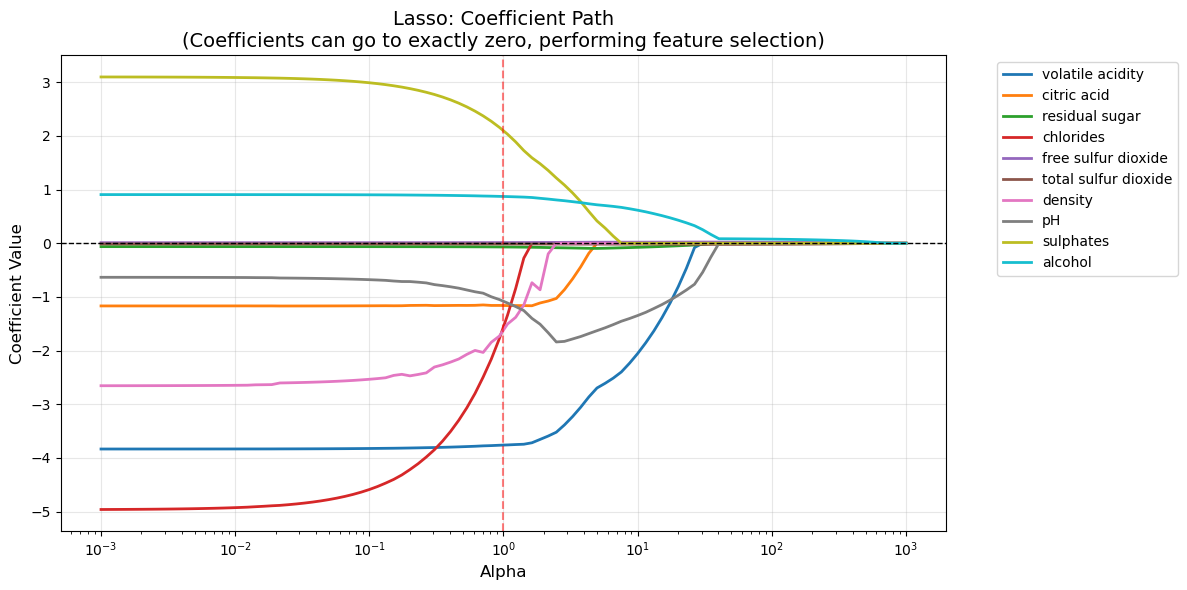

In [21]:

alpha_values = np.logspace(-3, 3, 100)  # C from 0.001 to 1000
coefs_lasso = []

for alpha in alpha_values:
    lasso = sk.linear_model.LogisticRegression(penalty='l1', solver='liblinear', C=1/alpha, random_state=42, max_iter=1000)
    lasso.fit(X_train, y_train)
    coefs_lasso.append(lasso.coef_[0])

# Plot coefficient path
plt.figure(figsize=(12, 6))
for i, feature in enumerate(X_train.columns):
    plt.plot(alpha_values, [coef[i] for coef in coefs_lasso], label=feature, linewidth=2)

plt.xscale('log')
plt.xlabel('Alpha', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)
plt.title('Lasso: Coefficient Path\n(Coefficients can go to exactly zero, performing feature selection)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', linewidth=1)
plt.axvline(x=1.0, color='r', linestyle='--', alpha=0.5, label='Current alpha=1.0')
plt.tight_layout()
plt.show()

The Lasso Regression coefficient path graph shows have the predictor variables coefficients change as the alpha increases from 0.001 to 1000, using the same bounds as were using in Ridge Regression. The main difference between Lasso and Ridge is that Lasso can force coefficients to be exactly zero, these variables that reach zero first are less important while those that maintain non zero coefficients are more important. This allows us to see the more important predictive variables in the model such as alcohol, pH and volatile acidity; all of which stay non zero for the longest.

Features selected by Lasso (alpha=1.0):
  Non-zero coefficients: 10/10
  Selected features: ['volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
  Eliminated features: None


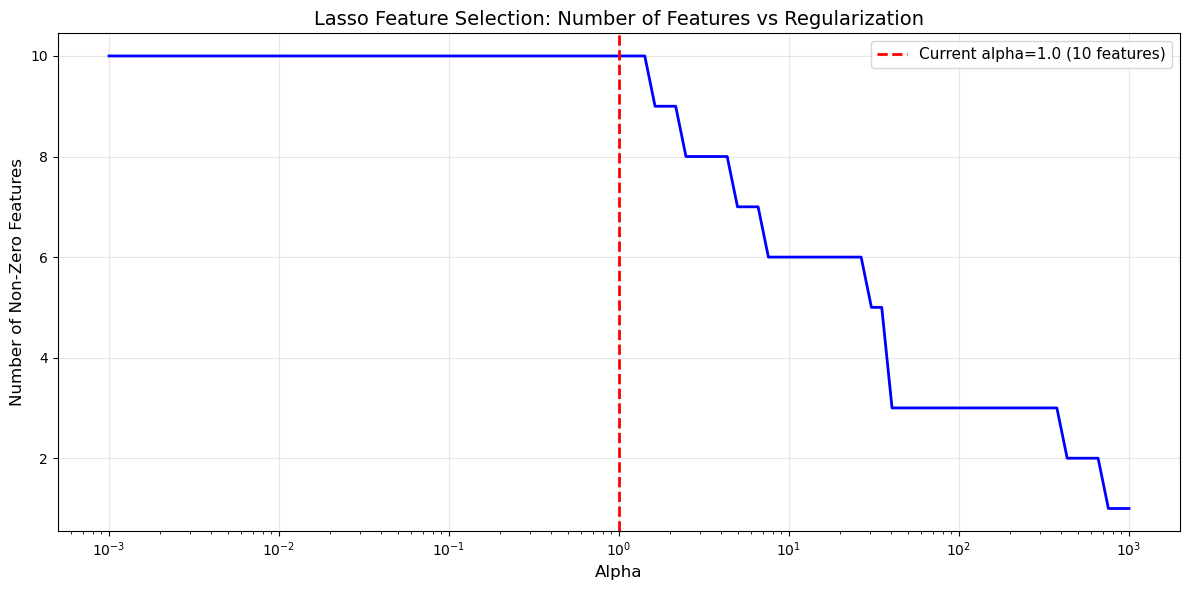

In [22]:
# 2. Feature Selection: Show which features survived (non-zero coefficients)
non_zero_features = X_train.columns[lasso_model.coef_[0] != 0]
zero_features = X_train.columns[lasso_model.coef_[0] == 0]

print(f"Features selected by Lasso (alpha={1/lasso_model.C}):")
print(f"  Non-zero coefficients: {len(non_zero_features)}/{len(X_train.columns)}")
print(f"  Selected features: {list(non_zero_features)}")
if len(zero_features) > 0:
    print(f"  Eliminated features: {list(zero_features)}")
else:
    print(f"  Eliminated features: None")

# Visualize feature selection across different C values
fig, ax = plt.subplots(figsize=(12, 6))
n_features = []
for alpha in alpha_values:
    lasso = sk.linear_model.LogisticRegression(penalty='l1', solver='liblinear', C=1/alpha, random_state=42, max_iter=1000)
    lasso.fit(X_train, y_train)
    n_features.append(np.sum(lasso.coef_[0] != 0))

ax.plot(alpha_values, n_features, 'b-', linewidth=2)
ax.axvline(x=1.0, color='r', linestyle='--', linewidth=2, label=f'Current alpha=1.0 ({len(non_zero_features)} features)')
ax.set_xscale('log')
ax.set_xlabel('Alpha', fontsize=12)
ax.set_ylabel('Number of Non-Zero Features', fontsize=12)
ax.set_title('Lasso Feature Selection: Number of Features vs Regularization', fontsize=14)
ax.grid(alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

The feature selection analysis for the Lasso Regression shows the quantity of predictor variables that remain as alpha increases. The dotted red line shows oour chosen alpha of 1 for training the model and that all 10 predictor variables ramain. As alha begins to increase past that point we were able to see the areas in which most of the predictor variables are forced to zero due to the alpha being sufficiently high, with the remaining three mentioned in the previous section as being more important remaining past an alpha of 100.

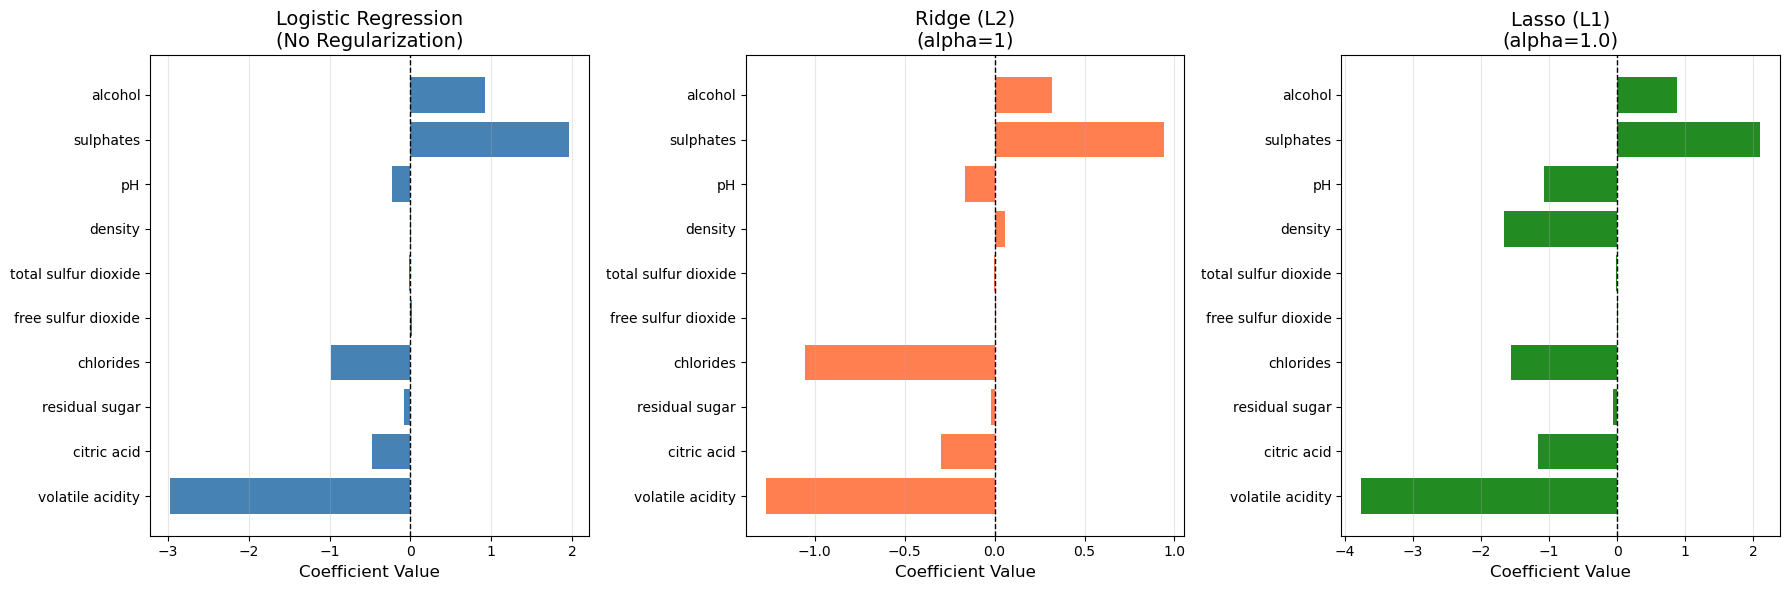


Coefficient Comparison Across All Models:
                Feature  Logistic   Ridge   Lasso
0      volatile acidity   -2.9724 -1.2738 -3.7596
1           citric acid   -0.4811 -0.2966 -1.1583
2        residual sugar   -0.0754 -0.0228 -0.0691
3             chlorides   -0.9792 -1.0546 -1.5623
4   free sulfur dioxide    0.0138  0.0058  0.0128
5  total sulfur dioxide   -0.0135 -0.0054 -0.0137
6               density    0.0111  0.0555 -1.6640
7                    pH   -0.2332 -0.1663 -1.0783
8             sulphates    1.9592  0.9442  2.0973
9               alcohol    0.9239  0.3202  0.8716


In [23]:
# 3. Compare All Three Models: Logistic, Ridge, Lasso
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Logistic Regression coefficients
axes[0].barh(X_train.columns, logistic_model.coef_[0], color='steelblue')
axes[0].set_xlabel('Coefficient Value', fontsize=12)
axes[0].set_title('Logistic Regression\n(No Regularization)', fontsize=14)
axes[0].axvline(x=0, color='k', linestyle='--', linewidth=1)
axes[0].grid(alpha=0.3, axis='x')

# Ridge coefficients
axes[1].barh(X_train.columns, ridge_model.coef_[0], color='coral')
axes[1].set_xlabel('Coefficient Value', fontsize=12)
axes[1].set_title(f'Ridge (L2)\n(alpha={ridge_model.alpha})', fontsize=14)
axes[1].axvline(x=0, color='k', linestyle='--', linewidth=1)
axes[1].grid(alpha=0.3, axis='x')

# Lasso coefficients
axes[2].barh(X_train.columns, lasso_model.coef_[0], color='forestgreen')
axes[2].set_xlabel('Coefficient Value', fontsize=12)
axes[2].set_title(f'Lasso (L1)\n(alpha={1/lasso_model.C})', fontsize=14)
axes[2].axvline(x=0, color='k', linestyle='--', linewidth=1)
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Coefficient comparison table
coef_comparison_all = pd.DataFrame({
    'Feature': X_train.columns,
    'Logistic': logistic_model.coef_[0],
    'Ridge': ridge_model.coef_[0],
    'Lasso': lasso_model.coef_[0]
})
print("\nCoefficient Comparison Across All Models:")
print(coef_comparison_all.round(4))

This comparison displays the coefficient values accross all three Regression models: Logistic, Ridge and Lasso. The Logistic Regression coefficients show the relationships without any penalty applied. The Ridge coefficients show the relationships with the L2 pentalty where they are shrunk towards zero but remain as non zero coefficients. The Lasso coefficients show the relationships with the L1 penalty applied where some coefficients are forced exactly to zero, none have been in our graph as we used an alpha that caused no coefficients to be forced to zero. Between all three graphs mostly the same predctor variables become prevalent with sulphates and volatile acidity standing out in all graphs whilst other factors like alcohol and chlorides have influential coefficients.

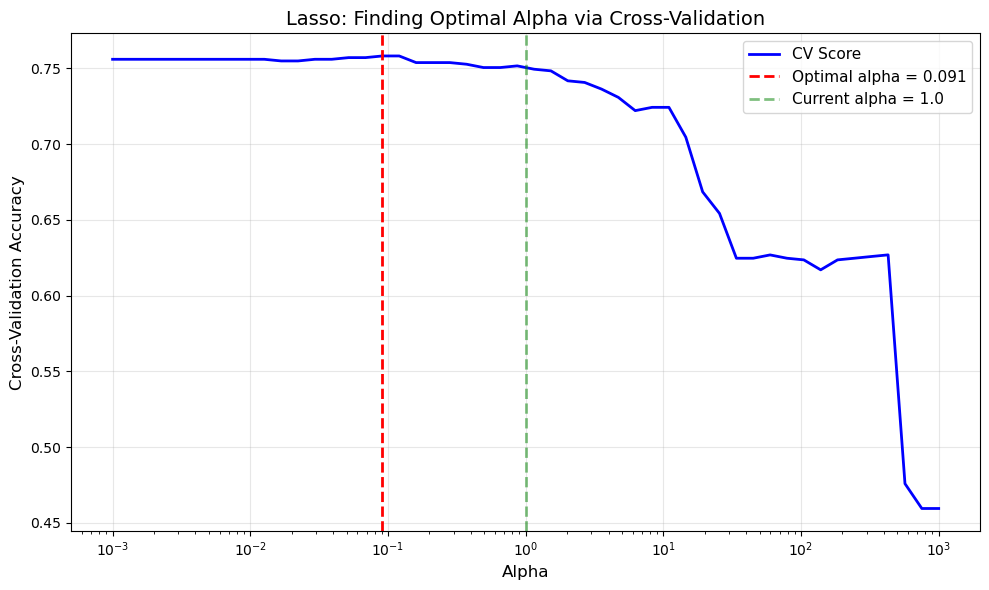


Optimal Alpha: 0.0910
Best CV Accuracy: 0.7582
Current C (1.0) CV Accuracy: 0.7517


In [24]:
from sklearn.model_selection import cross_val_score

alpha_values_cv = np.logspace(-3, 3, 50)
cv_scores_lasso = []

for alpha in alpha_values_cv:
    lasso = sk.linear_model.LogisticRegression(penalty='l1', solver='liblinear', C=1/alpha, random_state=42, max_iter=1000)
    scores = cross_val_score(lasso, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores_lasso.append(scores.mean())

# Find optimal alpha
optimal_alpha = alpha_values_cv[np.argmax(cv_scores_lasso)]
best_score_lasso = max(cv_scores_lasso)

# Plot cross-validation scores
plt.figure(figsize=(10, 6))
plt.plot(alpha_values_cv, cv_scores_lasso, 'b-', linewidth=2, label='CV Score')
plt.axvline(x=optimal_alpha, color='r', linestyle='--', linewidth=2, 
            label=f'Optimal alpha = {optimal_alpha:.3f}')
plt.axvline(x=1.0, color='g', linestyle='--', linewidth=2, alpha=0.5,
            label=f'Current alpha = 1.0')
plt.xscale('log')
plt.xlabel('Alpha', fontsize=12)
plt.ylabel('Cross-Validation Accuracy', fontsize=12)
plt.title('Lasso: Finding Optimal Alpha via Cross-Validation', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nOptimal Alpha: {optimal_alpha:.4f}")
print(f"Best CV Accuracy: {best_score_lasso:.4f}")
print(f"Current C (1.0) CV Accuracy: {cv_scores_lasso[np.argmin(np.abs(alpha_values_cv - 1.0))]:.4f}")

The CV analysis was done the same was as we did for Rdige, with a 5 fold CV used within an alpha range of 0.001 and 1000. We cacluated the accuracy for each alpha to determine which one determines the best model performance. The graph shows how accuracy changes as alpha increases, the best alpha represents the best balance between complexity and accuracy. By comparing the optimal alpha to our value of 1 we can assess that our model would benefit from lowering the alpha with the optimal being 0.0910. Once again though the change in accuracy is very small between the optimal alpha and our chosen value. The main difference is as alpha approaches 1000 the accuracy decreases more drastically than it does in Rdige.

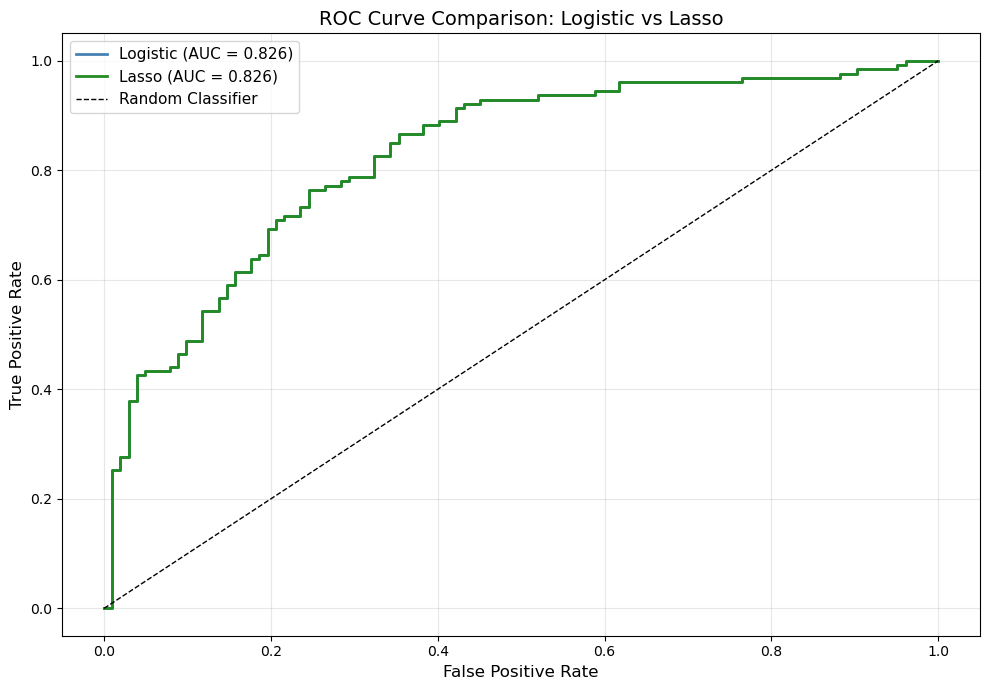

In [25]:
# 5. ROC Curve Comparison: Logistic vs Lasso
y_pred_proba_logistic = lasso_model.predict_proba(X_test)[:, 1]
y_pred_proba_lasso = lasso_model.predict_proba(X_test)[:, 1]

fpr_logistic, tpr_logistic, _ = sk.metrics.roc_curve(y_test, y_pred_proba_logistic)
fpr_lasso, tpr_lasso, _ = sk.metrics.roc_curve(y_test, y_pred_proba_lasso)

auc_logistic = sk.metrics.roc_auc_score(y_test, y_pred_proba_logistic)
auc_lasso = sk.metrics.roc_auc_score(y_test, y_pred_proba_lasso)

plt.figure(figsize=(10, 7))
plt.plot(fpr_logistic, tpr_logistic, label=f'Logistic (AUC = {auc_logistic:.3f})', linewidth=2, color='steelblue')
plt.plot(fpr_lasso, tpr_lasso, label=f'Lasso (AUC = {auc_lasso:.3f})', linewidth=2, color='forestgreen')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison: Logistic vs Lasso', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The ROC comparison shows the performance of Logistic vs Lasso Regression in terms of their ability to distinguish between the classes. The AUC score quanitifies overall perforamnce with values closer to 1 indicating better classification ability. We plotted both models on the same graph to see if the L1 penalty applied imporves predictive performance compared to stnadard or not. A higher AUC indicates the moodel is better at predicting both positive and negative cases. Due to the alpha we chose not being high enough to force any coefficients to zero, the model performs the exact same as the Logistic Regression model therefore indicating that a change in alpha would provide a more comprehensive comparison between the models.

## Support Vector Machining

Support Vector Machines are a classification algorithm that works by finding the optimal hyperplanes to separate classes. The algorithm maximises the margins between the closest points of each class, known as support vectors, ensuring best possible separation. We used default parameters for this and later use the RBF kernel. RBF kernel allows SVM to handle non linear relationships by transforming data intoo a space where linear separation becomes possible. The model works by penalising misclassified points whilst maximising distance between decision boundary and the support vectors.

In [26]:
from sklearn import svm
svm_model = svm.SVC()
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

cm_svm = metrics.confusion_matrix(y_test, y_pred_svm)
cm_svm



array([[ 39,  63],
       [ 11, 116]])

In [27]:
tn, fp, fn, tp = cm_svm.ravel()                        # Ravel the true negatives, false positives, false negatives and true positives from the confusion matrix

accuracy = (tp +tn) / (tp +tn +fp +fn)                      # Calculate overall accuracy, proportion of correct predictions vs population
sensitivity = (tp) / (tp + fn)                              # Calculate senstivity, proportion of true positives vs correct positives
specificity = (tn) / (tn + fp)                              # Calculate specificity, proportion of true negatives vs correct negatives
ppv = (tp) / (tp + fp)                                      # Calculate positive predictive value, proportion of true positives vs total predicted positives
npv = (tn) / (tn + fn)                                      # Calculate negative predictive value, proportion of true negatives vs total predicted negatives
prevalence = (tp + fn) / (tp + tn + fp + fn)                # Calculate prevalence, proportion of correct postives vs population
detection_rate = (tp) / (tp + tn + fp +fn)                  # Calculate detection rate, proportion of true positives vs population
detection_prevalence = (tp + fp) / (tp + tn + fp + fn)      # Calculate detection prevalence, proportion of predicted positives vs population
balanced_accuracy = (sensitivity + specificity) / 2         # Calculate balanced accuracy, mean of senstivity and specificity scores
kappa = sk.metrics.cohen_kappa_score(y_test, y_pred_svm)        # Kappa score, 0.5 means moderate agreement

n = len(y_test)
z = 1.96
ci_lower = (accuracy + z**2/(2*n) - z * np.sqrt((accuracy*(1-accuracy) + z**2/(4*n))/n)) / (1 + z**2/n)     # Lower confidence interval at 95%
ci_upper = (accuracy + z**2/(2*n) + z * np.sqrt((accuracy*(1-accuracy) + z**2/(4*n))/n)) / (1 + z**2/n)     # Upper confidence interval at 95%

print("Confusion Matrix:")                                              # Format results in the samw why R produces the results from a confusion matrix                                                                                                                                                 
print(f"           Prediction")                                                                                                                                            
print(f"              0      1")                                                                                                                                           
print(f"Actual 0    {tn:3d}   {fp:3d}")                                                                                                                                    
print(f"Actual 1    {fn:3d}   {tp:3d}")                                                                                                                                    
print()                                                                                                                                                                   
print(f"               Accuracy : {accuracy:.4f}")                                                                                                                        
print(f"                 95% CI : ({ci_lower:.4f}, {ci_upper:.4f})")                                                                                                                                                                                                                                                                                                                                                          
print()                                                                                                                                                                    
print(f"                  Kappa : {kappa:.4f}")                                                                                                                                                                                                                          
print()                                                                                                                                                                    
print(f"            Sensitivity : {sensitivity:.5f}")                                                                                                                     
print(f"            Specificity : {specificity:.5f}")                                                                                                                      
print(f"         Pos Pred Value : {ppv:.5f}")                                                                                                                              
print(f"         Neg Pred Value : {npv:.5f}")                                                                                                                              
print(f"             Prevalence : {prevalence:.5f}")                                                                                                                       
print(f"         Detection Rate : {detection_rate:.5f}")                                                                                                                   
print(f"   Detection Prevalence : {detection_prevalence:.5f}")                                                                                                             
print(f"      Balanced Accuracy : {balanced_accuracy:.5f}")   


Confusion Matrix:
           Prediction
              0      1
Actual 0     39    63
Actual 1     11   116

               Accuracy : 0.6769
                 95% CI : (0.6138, 0.7341)

                  Kappa : 0.3114

            Sensitivity : 0.91339
            Specificity : 0.38235
         Pos Pred Value : 0.64804
         Neg Pred Value : 0.78000
             Prevalence : 0.55459
         Detection Rate : 0.50655
   Detection Prevalence : 0.78166
      Balanced Accuracy : 0.64787


SVM has a lower accuracy than was seen in the previous Regression models. It also has a much poorer kappa, trending towards no better than chance. It has producded a very good sensitivity scoore indicating it is very effective at predicting correct positive cases but a very poor specificity indicating that it struggles to correctly predict correct negative cases.

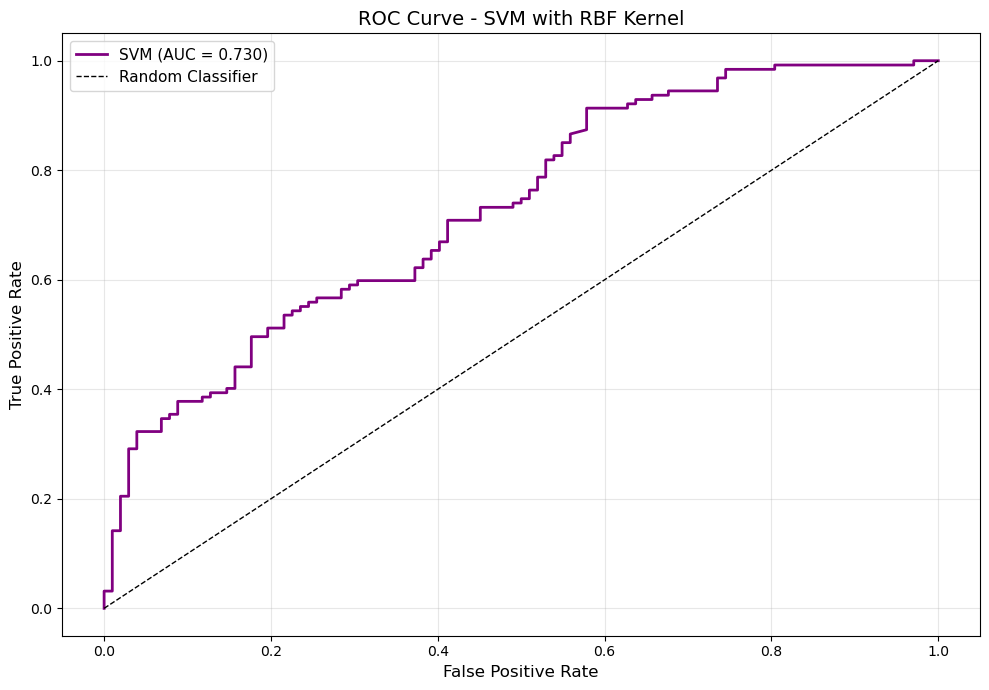

SVM AUC Score: 0.7299


In [28]:
# ROC Curve for SVM (need to retrain with probability=True)
svm_model_proba = svm.SVC(probability=True, random_state=42)
svm_model_proba.fit(X_train, y_train)

y_pred_proba_svm = svm_model_proba.predict_proba(X_test)[:, 1]

fpr_svm, tpr_svm, _ = sk.metrics.roc_curve(y_test, y_pred_proba_svm)
auc_svm = sk.metrics.roc_auc_score(y_test, y_pred_proba_svm)

plt.figure(figsize=(10, 7))
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})', linewidth=2, color='purple')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - SVM with RBF Kernel', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"SVM AUC Score: {auc_svm:.4f}")

SVM having a lower AUC than the Regression models chosen previously indicates that it has lower performance as an overall model and that it is not as good at correctly identifying both positive and negative cases. This makes sense due to having such a high sensitivity and low specificity as shown from the confusin matrix. The model is very good at identifying positive cases and poor at identifying negative cases.

## K Nearest Neighbors 

K-Nearest Neighbors, or KNN, is a supervised machine learning algorithm that works by considering the classes of the closest points. It works for classification as essentially a voting system, where the point is assigned to a class by taking the majority of its "neighbors". While there are many variations using different formulas, the most common type is computing the nearest neighbors with the Euclidean Distance. This distance formula could be thought of as drawing a straight line between the two points, where the measurement is of the length of the line. Formally it is represented by the square root of the sum of the squared differences for all features between two points.

The first step that is needed for a KNN classifier is to scale our training and test data. Because the algorithm works on a distance based metric, values from a higher scale will skew the distance calculation. The below code fits a scaler to the training and test data, transforming it based on this formula: z = (x - u) / s. Where z is the new scaled value, x is the original value, u is the mean, and s is the standard deviation. Now every feature will have a mean of 0 and a standard deviation of 1. 

In [29]:
scaler = sk.preprocessing.StandardScaler() 
scaleTrain, scaleTest = scaler.fit_transform(X_train), scaler.transform(X_test)

Next we will fit the KNN algorithm to the training data and compute its accuracy on the test data. However, the most important part of the KNN algorithm is choosing which value K will take. Or how many neighbors will be considered when choosing which class to take. A too low value of K will lead to potential outliers having too much noise in the decision, while too high of a value leads to over simplification in the decision. Another way to think of this tradeoff is that small values of K lead to overfitting while large values of K lead to underfitting.

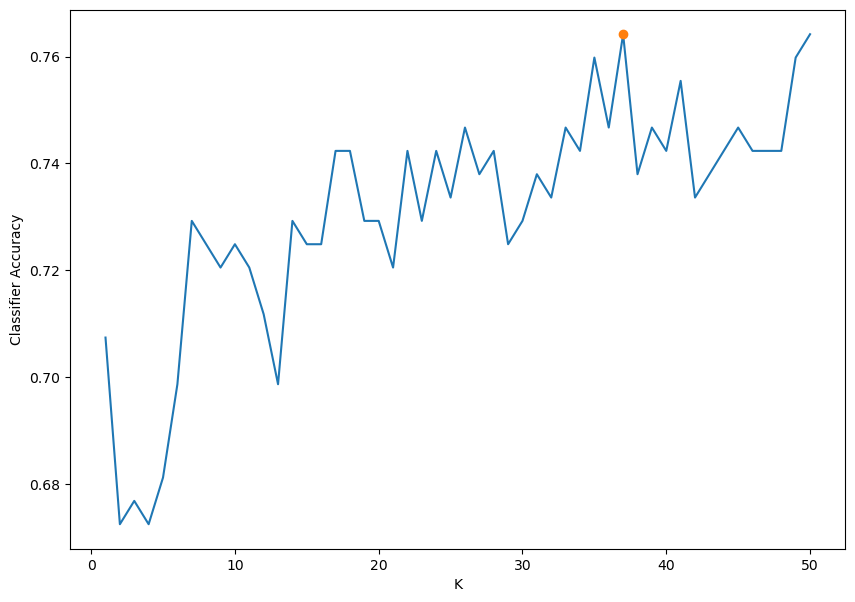

In [30]:
from sklearn import neighbors
k = [i for i in range (1,51)]
scores = []
for x in k:
    knn = sk.neighbors.KNeighborsClassifier(n_neighbors=x)
    knn.fit(scaleTrain, y_train)
    score = knn.score(scaleTest, y_test)
    scores.append(score)

bestAccuracy = max(scores)
bestK = scores.index(bestAccuracy) + 1

plt.figure(figsize = (10, 7))
plt.plot(k, scores)
plt.plot(bestK, bestAccuracy, marker = 'o')
plt.xlabel("K")
plt.ylabel("Classifier Accuracy")
plt.show()

After tuning the parameter for K, the best model had a prediction accuracy of 76% with a value of K set to 37. This means that each new point will be classified based on the majority of classes among its 37 nearest neighbors.

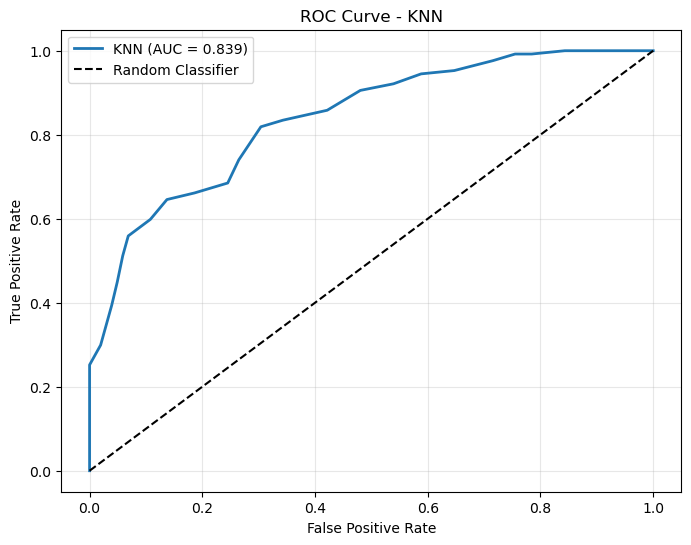

In [31]:
knnModel = sk.neighbors.KNeighborsClassifier(n_neighbors = 37)
knnModel.fit(scaleTrain, y_train)
knn_pred_prob = knnModel.predict_proba(scaleTest)[:, 1]
fpr, tpr, thresholds = sk.metrics.roc_curve(y_test, knn_pred_prob)                                                                                                                     
auc_score = sk.metrics.roc_auc_score(y_test, knn_pred_prob)                                                                                                                            

plt.figure(figsize=(8, 6))                                                                                                                                                 
plt.plot(fpr, tpr, label=f'KNN (AUC = {auc_score:.3f})', linewidth=2)                                                                                      
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')                                                                                                                 
plt.xlabel('False Positive Rate')                                                                                                                                          
plt.ylabel('True Positive Rate')                                                                                                                                           
plt.title('ROC Curve - KNN')                                                                                                                               
plt.legend()                                                                                                                                                               
plt.grid(alpha=0.3)                                                                                                                                                        
plt.show()  

## Random Forest 
A decision tree is one of the easier classifiers to visualize, as it works like a flowchart. At each step, the tree branches out based on whether a feature meet a certain criteria. For example, the first split might be on whether a wine has an alcohol content of more or less than 10. Then more branches will form off of either having a higher or lower alcohol content. The tree will make its final classification based on the majority of classes present at the end of the tree, or the terminal nodes.

A classification tree chooses which feature to split on by preforming a greedy search at each level based on the Gini Index. The Gini index is a measure of a node's purity, or how much of the node is composed of a single class. It is calculated by multiplying the proportion of a certain class in a node by 1 - the proportion. This calculation is preformed for all classes and the results are summed to create the Gini Index value. Therefore, a lower value indicates that the node is made up of primarily one class. The greedy search means that the tree will pick strictly on which feature leads to the greatest reduction in the Gini index.

However, a decision tree does not generally have a very high predictive accuracy, which is why we use Random Forests instead. A Random Forest is an amalgamation of multiple decision trees, where the final decision is built from the majority of the trees. However, the trees need to be different from one another or else there is no point in building the forest. 

The first difference occurs when selecting the data to be used in the training of the trees. A Random Forest uses a bootstrap sample, which means it samples with replacement from the original training data set. So theoretically a bootstrap sample could be the same as the original training data set, or it could by solely made up of one instance from the training set. Therefore the information available to each tree within the forest will be slightly different.

A second difference is that each tree will choose to split on only a subsection of the features. For instance, if our Random Forest model has an m value (max features to consider) of 2, then a tree will make its splitting at that level based on only the two randomly selected features. The typical value of m to use is the square root of the total number of features, which in this case would be roughly 3. However since this data set is not particularly large, we can construct a random forest for all possible values of m. 

In [32]:
from sklearn import ensemble
accuracy = []
mValues = range(1,12)
for m in mValues: #for every value of m between 1 and 11
    rf = sk.ensemble.RandomForestClassifier(
        bootstrap = True,
        n_estimators = 100,
        max_features = m,
        random_state = 42
    )
    rf.fit(X_train, y_train)
    accuracy.append(rf.score(X_test, y_test)) #Adds the average seed accuracy from the particular m value to the accuracy list

Best accuracy = 0.7903930131004366 from m value = 2


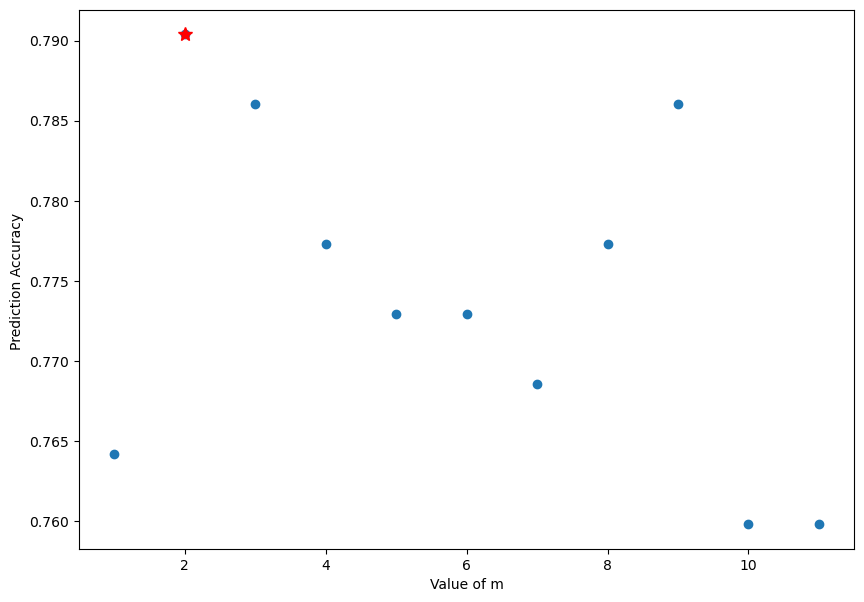

In [33]:
plt.figure(figsize=(10, 7))
plt.scatter(mValues, accuracy, marker = 'o')
plt.xlabel("Value of m")
plt.ylabel("Prediction Accuracy ")
plt.plot(mValues[accuracy.index(max(accuracy))], max(accuracy), marker = '*', color = 'r', ms = 10)
print("Best accuracy = " + str(max(accuracy)) + " from m value = " + str(accuracy.index(max(accuracy)) + 1))
    


As can be seen in the above graph, the m value that achieved the highest average prediction accuracy was equal to 2. This achieved a prediction accuracy of 79% for whether a wine is above or below average.
The optimized parameter indicates that the best model only considered two randomly drawn features on each level of a tree. The second highest value was equal to 3, which is the closest equivalent to the square root of the total number of features.

## Gradient Boosting

Gradient boosting is another alternative to a decision tree that works by incrementally building trees that learn from the errors made by previous trees. The algorithm starts by finding the initial probability that any instance would belong to a particular class, in this case to an above average wine. 

In [34]:
below = y_train.value_counts()[0]
above = y_train.value_counts()[1]
logOdd = np.log(above/below)
initialProb = np.exp(logOdd) / (1 + np.exp(logOdd))
initialProb

0.5404814004376367

Because this probability is greater than 0.5, the initial step classifies each instance as belonging to class 1 (above average wine). The next step calculates the pseudo residuals for every instance. The pseudo residual is equal to the difference between the observed value, from the training set, and the expected value, the probability calculated in the above code. Since there are are only two classes to be predicted, the pseudo residuals will be either 0.46 (for the wines with an above average quality) or -0.54 (for the wines with a below average quality). 

After that, a decision tree is constructed to predict the pseudo residuals based on the features in the training data set. This tree will be smaller than a regular decision tree, with a parameter limiting the number of terminal nodes in the tree. This is a parameter that will be tuned and assessed for the final model.

Once the tree has been constructed, the pseudo residuals in each terminal node are used to construct new values that modify the probability of being an above average wine for each instance. This value is scaled by a small learning rate which both typically and in this case, will be set to 0.1. 

After the new probabilities have been generated, the same process as before occurs for every instance. Where new psuedo residuals are created by subtracting the observed from the expected. This process will continue to iterate, building new trees to estimate the pseudo residuals based on the values from the previous generation. Its important to note that each generation is saved and continues to build on each other, no values are deleted from the model. The process will end after it has completed the specified number of iterations. 

In [35]:
maxNodes = [2, 3, 4, 5]
iterations = range(100, 501, 10)
accuracy = []
for n in maxNodes:
    for i in iterations:
        gbc = sk.ensemble.GradientBoostingClassifier(
            loss = 'log_loss',
            learning_rate = 0.1,
            max_depth = n,
            n_estimators = i,
            random_state = 42
        )
        gbc.fit(X_train, y_train)
        accuracy.append(gbc.score(X_test, y_test))

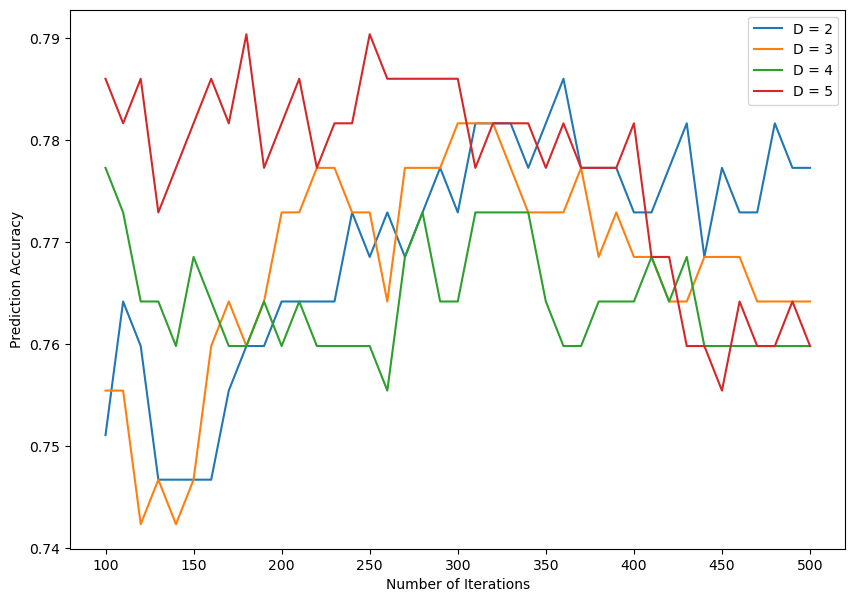

In [36]:
plt.figure(figsize = (10, 7))
plt.plot(iterations, accuracy[0:41], label = "D = 2")
plt.plot(iterations, accuracy[41:82], label = 'D = 3')
plt.plot(iterations, accuracy[82:123], label = "D = 4")
plt.plot(iterations, accuracy[123:164], label = "D = 5")
plt.legend()
plt.xlabel("Number of Iterations")
plt.ylabel("Prediction Accuracy")
plt.show()

The resulting graph from plotting each of the different parameters is quite noisy. But it is clear to see that the best accuracy was found by setting the maximum number of terminal nodes to 5. There are however a couple of different values for the number of iterations that results in a similar accuracy. So a closer examination into that particular graph would be helpful.

In [37]:
d5Acc = []
iterations = range(150, 301, 10)
for i in iterations:
    gbc = sk.ensemble.GradientBoostingClassifier(
        loss = 'log_loss',
        learning_rate = 0.1,
        max_depth = 5, 
        n_estimators = i,
        random_state = 42
    )
    gbc.fit(X_train, y_train)
    d5Acc.append(gbc.score(X_test, y_test))

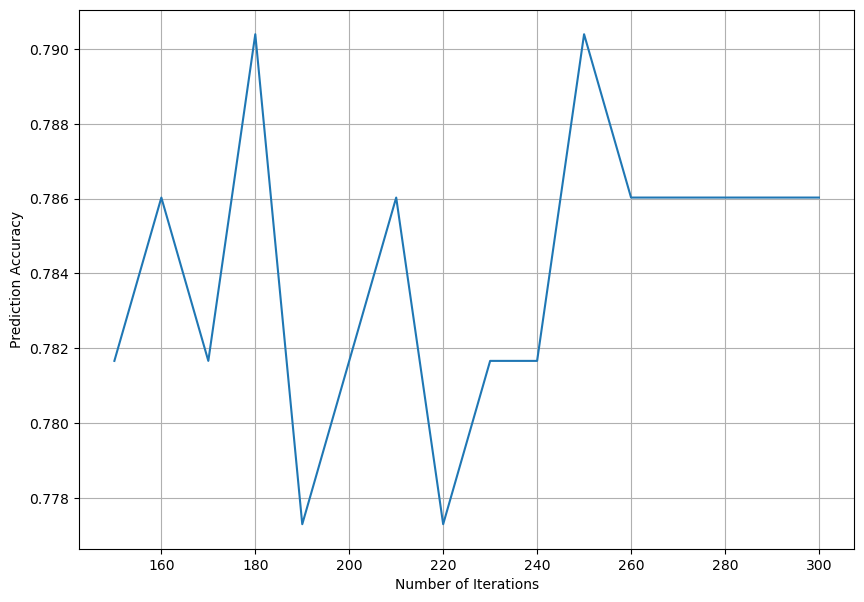

In [38]:
plt.figure(figsize = (10, 7))
plt.plot(iterations, d5Acc)
plt.xlabel("Number of Iterations")
plt.ylabel("Prediction Accuracy")
plt.grid()
plt.show()

The graph shows that 180, 250, 260, and 300 iterations all produce a very close if not equal prediction accuracy. While Gradient Boosting is quite resilient to overfitting, choosing the smallest number of iterations does reduce the chance of the model overfitting to the training data. Therefore the best model is built on having a maximum number of nodes equal to 5 and it will run for 180 iterations. 


## Neural Networks 

Deep learning is a subfield of machine learning that focuses around building collections of layers that influence the input data. As the data passes through each layer, weights and biases will linearly transform their input values into a weighted sum. Before passing along this single output to the next layer. There is no hard or fast rule for the amount of layers or the composition of the layers, and these factors will widely vary from model to model. One important piece of terminology that will be used in this section is that the nodes or objects within each layer are referred to as neurons.

For this Neural Network model, our input is 11 variables representing different scientific components of a wine and the output is the probability that the wine belongs to either class. So the first two things known about this model is that the first layer will be composed of 11 neurons, and the final layer will have only two neurons. Another piece of information that can be gleaned is what type of activation function will be applied to this model. An activation function is applied to each neuron after completing the summation of the input values transformed by the weights and biases. This function is included to introduce non-linearity into the model. Because this model is predicting the probability of belonging to a class, the logistic sigmoid function is used to cast all values between 0 and 1.

Now that the general setup is understood, the model needs to begin training. The goal of the model is at essence the same as other machine learning models, to optimize a function that minimizes the difference between predicted and observed values. Since this is a classification model, the goal will be to minimize cross-entropy. The minimization of the difference is also referred to as the loss function. The parameters to the prediction function that are being trained are the weights and biases. There are multiple different formulas and algorithms to calculate these weights, but this model will use mini-batch gradient descent.

All gradient descent algorithms iteratively calculate the partial derivative of the loss function and use that value to update the weights in a way that leads to the largest reduction in the loss function. This change in the weights is controlled by a learning rate parameter, which slows the effect of each iteration. This parameter will be tuned in the final model.

At the beginning all the weights are randomly chosen, and the gradient descent calculates the changes in the weights. The weights are updated and the same process is carried out until a certain amount of iterations is reached or the change in the gradient is very small. A normal, or vanilla, gradient descent algorithm uses all the samples in the training set to calculate the gradient descent before updating the weights. A stochastic gradient descent differs in that it will randomly select one instance from the training set to update the weights.

There are tradeoffs for both of those types of gradient descent. Vanilla will consider the entire training set so it can be very computationally expensive, however it will provide the most well rounded solution. Since stochastic randomly selects one sample, the change in the weights can be quite drastic but it calculates the change quickly. Mini-batch offers a combination of the two, where the data is randomly divided into small sub groups and the weights are updated one mini-batch at a time. Therefore it effectively balances the accuracy and speed of the other two.

The last piece of information to note before evaluating the model is that a neural network is sensitive to varying values across the input features. However, scaling was already done in the KNN portion of the report, so that will be the training set used.

In [39]:
%%capture
from sklearn import neural_network
learningRates = [.001, .01, .1]
iterations  = range(1, 151)
accuracy = []

for lr in learningRates:
    for i in iterations:
        neuralNetwork = sk.neural_network.MLPClassifier(
            random_state= 42, 
            solver= 'sgd', #Set to use the Stochastic Gradient Descent
            activation = 'logistic', #Activation function of logistic sigmoid function
            shuffle = True, #makes sure the model randomly sorts the training data
            batch_size = 32, #The size of the mini batch
            learning_rate = 'constant', #Specifies to use a consistent training rate value
            learning_rate_init = lr, #Here we will tune the learning rate parameter by setting to different values 
            max_iter = i
            ).fit(scaleTrain, y_train)
        accuracy.append(neuralNetwork.score(scaleTest, y_test))

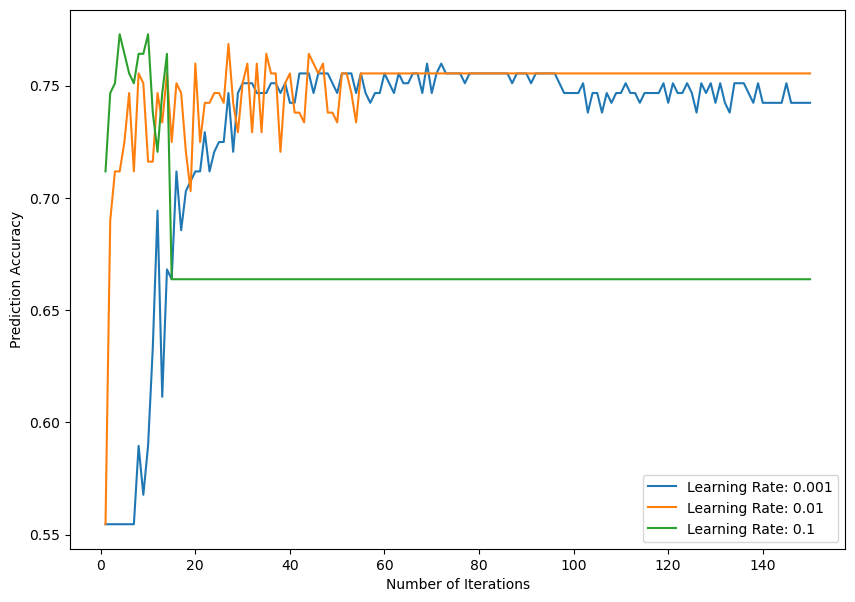

In [40]:
plt.figure(figsize=(10,7))
plt.plot(iterations, accuracy[0:150], label = "Learning Rate: 0.001")
plt.plot(iterations, accuracy[150:300], label = "Learning Rate: 0.01")
plt.plot(iterations, accuracy[300:450], label = "Learning Rate: 0.1")
plt.xlabel("Number of Iterations")
plt.ylabel("Prediction Accuracy")
plt.legend()
plt.show()

What this graph shows is the tradeoff that occurs when selecting the learning rate for a neural network. The model with the highest learning rate stopped its training the earliest, but it finished with by far the lowest prediction accuracy. The other models both finished with a roughly equivalent prediction accuracy, and it appears that the lowest learning rate will level out roughly equivalent to the middle learning rate. So the best model would have a learning rate of 0.01, as it achieves a high prediction accuracy but finishes computing at a quicker rate. In this case, the model finished with a prediction accuracy of around 75%. 

## Conclusion

This report successful applied multiple Machine Learning Classification methods to predict wine quality based on a number oof predictor variables, demonstrating that ensemble methods ooutperformed indiviudal classifiers for this task. Our analysis of different classification methods revealed strengths and limitations across statistical methods, distance based algorithms, ensemble methods and deep learning. Random Forest came out as the best performing method with an accuracy of 79.47% using an m value of 2. This better performance can be from the ensemble methods ability to combine multiple weak learners whilst reducing overfitting. The success of Random Forest demonstrates that for this dataset the more complex non linear relationships between the predictor variables and qine quality are better seen through ensemble methods than linear or single model methods.

The GLM methods performed reasonably well with accuracies all around 76%. The methods provided insights into the importance of certain predictor variables and the role of regularisation based on multicollinearity between said predictor variables addressed with Lasso and Ridge Regression methods. The coefficient analysis across all the models consistently identifiend alcohol content, sulphites and volatile acidity as the most important predictors which stayed in line with the correlation analysis from our EDA. SVM with RBF underperformed with only an accuracy of 67.69% accuracy showing the poor class balance with a very high sensitivity at 91.3% and low specificity at 38.2%. This showed that SVM struggled to show an effective decision boundary potentially due to the overlap between quality classes.

KNN achieved a 76% accuracy with a K of 37. This showed the effectiveness of distance based classifications after scaling. The relatively high value of K for optimal performance however suggests that the decision boundaries between classes are not sharply defined requiring the consideration of multiple neighbours for reliable predictions. Neural networks achieved an accuracy of 75% despite the ability to do complex learning patterns. Whilst having a similar accuracy, the Neural Network did not outperform the simpler appreoaches potentially due to the dataset not being large enough for it to perform to its full extent.

In conclusion this report shows that machine learning, mainly ensemble methods, can accurately predict wine quality from the predictor variables with the most important predictor variables being alcohol content, sulphates and volatile acidity.
